# Clinical analysis of CDK4/6 mutations

In [11]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
import re
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

In [13]:
cases = pd.read_excel('Case_series_cdk_mut.xlsx').dropna(subset='mutation').reset_index(drop=True)



def extract_numbers(text):
    """Extracts all numbers from the given text."""
    return [int(i) for i in re.findall(r'\d+', text)][0]

cases['codon'] = [extract_numbers(i) for i in cases['mutation']]
cases

,Patient_ID (record ID),Tumor sample,Disease history,gene,mutation,Specific missense present in database,other relevant,Sequencing time (before vs. after ET+/=CDK4/6i),codon
0,665,P-0000015-T01-IM3,Progression very end adjuvant treatment. Tam 1...,CDK4,p.D196H,yes,"PIK3CA E545K, ESR1 p.L536H, TP53",After,196
1,2747,P-0012532-T01-IM5,"ngs (CDK) --> Adjuvant ET therapy, ongoing (~2...",CDK4,p.D84H,yes,"PIK3CA p.H1047R, TP53",before,84
2,2742,P-0016773-T01-IM6,"ngs (CDK) --> Adjuvant ET, ongoing 9 years",CDK4,p.R240Q,yes,"MSI, TMB 400",before,240
3,4022,P-0026885-T01-IM6,local recurrence after 10years --> ngs (CDK) ...,CDK4,p.E263K,no (same codon),TMB 157,before,263
4,2038,P-0030800-T01-IM6,recurrence 2 y on adjuvant ET --> ngs (CDK) --...,CDK6,p.R46Q,no (same codon),FAT1,before,46
5,4676,P-0035157-T01-IM6,"ngs (CDK) --> adjuvant Tam 5 years, no PD",CDK6,p.A259V,yes,PIK3CA p.H1047L,before,259
6,7818,P-0081718-T01-IM7,ngs (CDK) --> exemestane/palbo PFS ~16 mo -->...,CDK6,p.L105F,yes,"PIK3CA p.E545K, TP53 (both confirmed on both n...",before and post,105
7,3370,P-0018893-T01-IM6,dx mets --> ngs (CDK) --> 1L paclitaxel --> 2L...,CDK4,p.E94Q,yes,NA (19 muts),before,94
8,1601,P-0004537-T01-IM5,adjuvant anastrozole 5 mo DFS --> ngs (CDK) --...,CDK6,p.D102N,no codon matching,"TP53, NF1",NaN,102
9,1438,P-0008398-T02-IM6,ngs (no CDK) --> 1L tamoxifen 18 mo --> AI/pal...,CDK4,p.I284M,no codon matching,NaN,after,284


In [8]:
ABE_master = pd.read_csv('../../screening_data/03_LFC_FDR_tables/ABE_master_LFC_table.csv')
CBE_master = pd.read_csv('../../screening_data/03_LFC_FDR_tables/CBE_master_LFC_table.csv')

ABE_editing = pd.read_csv('../../screening_data/04_editing/ABE_editing_master.csv')
CBE_editing = pd.read_csv('../../screening_data/04_editing/CBE_editing_master.csv')

In [52]:
min_edit = 20

abe_cdk4 = ABE_editing[(ABE_editing['Gene']=='CDK4') & (ABE_editing['%Reads']>=min_edit) & (ABE_editing['Codon']!='WT')]
abe_cdk6 = ABE_editing[(ABE_editing['Gene']=='CDK6') & (ABE_editing['%Reads']>=min_edit) & (ABE_editing['Codon']!='WT')]
cbe_cdk4 = CBE_editing[(CBE_editing['Gene']=='CDK4') & (CBE_editing['%Reads']>=min_edit) & (CBE_editing['Codon']!='WT')]
cbe_cdk6 = CBE_editing[(CBE_editing['Gene']=='CDK6') & (CBE_editing['%Reads']>=min_edit) & (CBE_editing['Codon']!='WT')]


cdk4_muts = pd.concat((abe_cdk4, cbe_cdk4))
cdk6_muts = pd.concat((abe_cdk6, cbe_cdk6))


cdk4_muts['Codon'] = [int(i) for i in cdk4_muts['Codon']]
cdk6_muts['Codon'] = [int(i) for i in cdk6_muts['Codon']]

In [58]:
cdk4_cases = cases[cases['gene']=='CDK4']
cdk6_cases = cases[cases['gene']=='CDK6']

cdk4_mut_subset = cdk4_muts[cdk4_muts['Codon'].isin(list(cdk4_cases['codon']))]
cdk6_mut_subset = cdk6_muts[cdk6_muts['Codon'].isin(list(cdk6_cases['codon']))]

print(list(np.unique(cdk4_mut_subset['Codon'])))
print(sorted(list(cdk4_cases['codon'])))
print(list(np.unique(cdk6_mut_subset['Codon'])))
print(sorted(list(cdk6_cases['codon'])))

[84, 94, 162, 166, 196, 240, 263, 284]
[84, 94, 162, 166, 196, 240, 263, 284]
[18, 46, 86, 105, 168, 220, 259, 297]
[18, 46, 86, 102, 105, 168, 220, 259, 297]


In [81]:
abe_cdk4_guides = np.unique(cdk4_mut_subset[cdk4_mut_subset['Editor']=='ABE']['gRNA_id'])
cbe_cdk4_guides = np.unique(cdk4_mut_subset[cdk4_mut_subset['Editor']=='CBE']['gRNA_id'])
abe_cdk6_guides = np.unique(cdk6_mut_subset[cdk6_mut_subset['Editor']=='ABE']['gRNA_id'])
cbe_cdk6_guides = np.unique(cdk6_mut_subset[cdk6_mut_subset['Editor']=='CBE']['gRNA_id'])


cols = ['gRNA_id', 'LFC_median_RIBO_DMSO', 'LFC_median_PALBO_DMSO', 'LFC_median_ABEMA_DMSO', 'LFC_median_ATIRMO_DMSO', 'LFC_median_TAGTO_DMSO', 'LFC_median_INX_DMSO', 'FDR_RIBO_DMSO', 'FDR_PALBO_DMSO', 'FDR_ABEMA_DMSO', 'FDR_ATIRMO_DMSO', 'FDR_TAGTO_DMSO', 'FDR_INX_DMSO']
ABE_CDK4 = ABE_master[ABE_master['gRNA_id'].isin(abe_cdk4_guides)][cols].dropna()
CBE_CDK4 = CBE_master[CBE_master['gRNA_id'].isin(cbe_cdk4_guides)][cols].dropna()
ABE_CDK6 = ABE_master[ABE_master['gRNA_id'].isin(abe_cdk6_guides)][cols].dropna()
CBE_CDK6 = CBE_master[CBE_master['gRNA_id'].isin(cbe_cdk6_guides)][cols].dropna()




In [99]:
a4 = pd.merge(ABE_CDK4, cdk4_muts[cdk4_muts['Editor']=='ABE'], on='gRNA_id')
c4 = pd.merge(CBE_CDK4, cdk4_muts[cdk4_muts['Editor']=='CBE'], on='gRNA_id')
a6 = pd.merge(ABE_CDK6, cdk6_muts[cdk6_muts['Editor']=='ABE'], on='gRNA_id')
c6 = pd.merge(CBE_CDK6, cdk6_muts[cdk6_muts['Editor']=='CBE'], on='gRNA_id')

In [129]:
cdk4_full = pd.concat((a4, c4))
cdk6_full = pd.concat((a6, c6))

#then need to remove duplicate gRNAs
cdk4_filt = cdk4_full[cdk4_full['Codon'].isin(list(np.unique(cdk4_cases['codon'])))]
cdk4_filt = cdk4_filt.sort_values(by=['gRNA_id', '%Reads'], ascending=False).drop_duplicates(subset='gRNA_id')

cdk6_filt = cdk6_full[cdk6_full['Codon'].isin(list(np.unique(cdk6_cases['codon'])))]
cdk6_filt = cdk6_filt.sort_values(by=['gRNA_id', '%Reads'], ascending=False).drop_duplicates(subset='gRNA_id')

c_dict = {'ABE':'tab:purple', 'CBE':'tab:blue'}
cdk4_filt['color'] = [c_dict[i] for i in cdk4_filt['Editor']]
cdk6_filt['color'] = [c_dict[i] for i in cdk6_filt['Editor']]

In [143]:
def find_ranges(numbers):
    if not numbers:
        return []

    # Sort the list to ensure consecutive numbers are adjacent
    sorted_numbers = sorted(list(set(numbers)))  # Use set to handle duplicates

    ranges = []
    if not sorted_numbers:
        return ranges

    start_of_range = sorted_numbers[0]
    
    for i in range(1, len(sorted_numbers)):
        if sorted_numbers[i] != sorted_numbers[i-1] + 1:
            # End of current range, add it to the list
            ranges.append((start_of_range, sorted_numbers[i-1]))
            start_of_range = sorted_numbers[i] # Start a new range
    
    # Add the last range
    ranges.append((start_of_range, sorted_numbers[-1]))
    
    return ranges

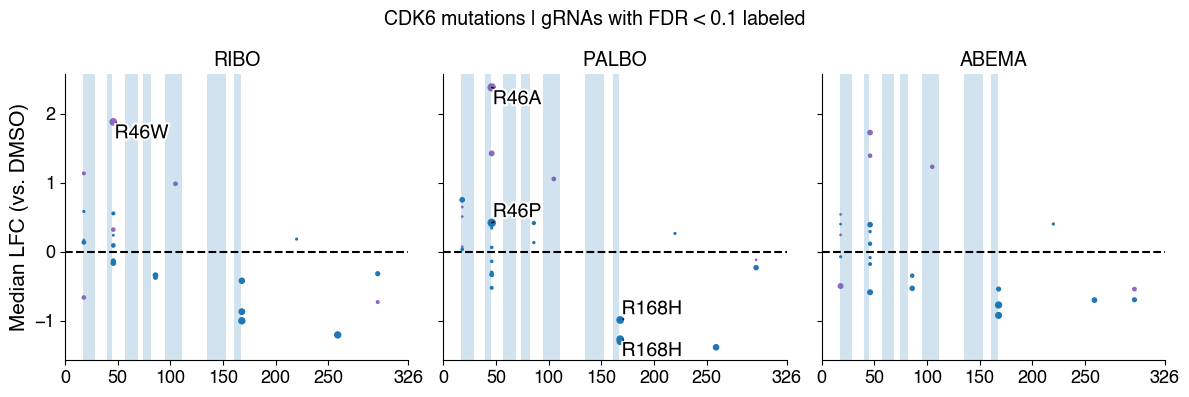

In [163]:
conditions = ['RIBO', 'PALBO', 'ABEMA']
FDR_cutoff_plot = 0.1

fig, ax = plt.subplots(1,3,figsize=(12,4), sharey=True)

for x, cond in enumerate(conditions):
    ax[x].scatter(cdk6_filt['Codon'], cdk6_filt[f'LFC_median_{cond}_DMSO'],s = 20*-np.log10(cdk6_filt[f'FDR_{cond}_DMSO'])+1, c=cdk6_filt['color'])

    bb2 = cdk6_filt[cdk6_filt[f'FDR_{cond}_DMSO']<FDR_cutoff_plot]
    t = list(bb2['HGVSp'])
    x2=list(bb2['Codon'])
    y = list(bb2[f'LFC_median_{cond}_DMSO'])

    
    texts = [ax[x].text(x2[i], y[i], t[i], fontsize=14, color='black', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                    foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    adjust_text(texts,only_move={'points':'xy', 'texts':'xy'}, ax=ax[x], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))

    ax[x].set_title(cond, fontsize=14)
    ax[x].set_xticks([0,50,100,150,200,250,326])
    ax[x].set_xlim(0,326)

    ax[x].spines[['right', 'top']].set_visible(False)
    ax[x].tick_params(axis='both', which='major', labelsize=13)
    ax[x].axhline(0, color='black', linestyle='dashed')

#finally, add the KLIFS pocket annotations
KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')
j = 'CDK6'
numbers = list(KLIFS[j].dropna())
r = find_ranges(numbers)
for a in range(3):
    for k in r:
        ax[a].axvspan(k[0],k[1], alpha=.2)

ax[0].set_ylabel('Median LFC (vs. DMSO)', fontsize=15)

fig.suptitle(f'CDK6 mutations | gRNAs with FDR < {FDR_cutoff_plot} labeled', fontsize=14)

fig.tight_layout()

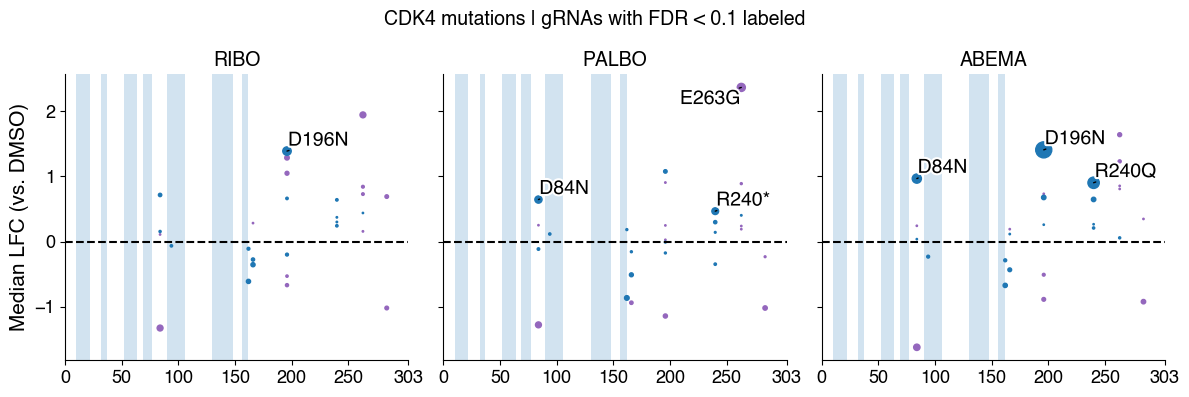

In [162]:
conditions = ['RIBO', 'PALBO', 'ABEMA']
FDR_cutoff_plot = 0.1

fig, ax = plt.subplots(1,3,figsize=(12,4), sharey=True)

for x, cond in enumerate(conditions):
    ax[x].scatter(cdk4_filt['Codon'], cdk4_filt[f'LFC_median_{cond}_DMSO'],s = 20*-np.log10(cdk4_filt[f'FDR_{cond}_DMSO'])+1, c=cdk4_filt['color'])

    bb2 = cdk4_filt[cdk4_filt[f'FDR_{cond}_DMSO']<FDR_cutoff_plot]
    t = list(bb2['HGVSp'])
    x2=list(bb2['Codon'])
    y = list(bb2[f'LFC_median_{cond}_DMSO'])

    
    texts = [ax[x].text(x2[i], y[i], t[i], fontsize=14, color='black', path_effects=[PathEffects.withStroke(linewidth=3,
                                                                                    foreground="w")]) for i in range(len(x2))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    adjust_text(texts,only_move={'points':'xy', 'texts':'xy'}, ax=ax[x], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))

    ax[x].set_title(cond, fontsize=14)

    ax[x].set_xticks([0,50,100,150,200,250,303])
    ax[x].set_xlim(0,303)
    ax[x].spines[['right', 'top']].set_visible(False)
    ax[x].tick_params(axis='both', which='major', labelsize=13)
    ax[x].axhline(0, color='black', linestyle='dashed')
    

#finally, add the KLIFS pocket annotations
KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')
j = 'CDK4'
numbers = list(KLIFS[j].dropna())
r = find_ranges(numbers)
for a in range(3):
    for k in r:
        ax[a].axvspan(k[0],k[1], alpha=.2)

ax[0].set_ylabel('Median LFC (vs. DMSO)', fontsize=15)

fig.suptitle(f'CDK4 mutations | gRNAs with FDR < {FDR_cutoff_plot} labeled', fontsize=14)

fig.tight_layout()
